In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Load data and model results
df = pd.read_csv('../data/features_dataset.csv', parse_dates=['date'])
results_df = pd.read_csv('../data/model_comparison.csv')

print("Best model:", results_df.iloc[0]['model'])
print(f"Best RMSE: {results_df.iloc[0]['rmse']:.4f}")
print(f"\nDataset shape: {df.shape}")
print(f"Range: {df['date'].min()} to {df['date'].max()}")

Best model: Naive Baseline
Best RMSE: 3.0717

Dataset shape: (61, 41)
Range: 2020-11-01 00:00:00 to 2025-11-01 00:00:00


In [2]:
# ============================================================
# REBUILDING THE BEST MODEL TO GENERATE THE PREDICTIONS
# ============================================================

from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error

# Define features
exclude_cols = ['date', 'target', 'target_direction', 'rate_regime']
feature_cols = [c for c in df.columns if c not in exclude_cols and df[c].dtype in ['float64', 'int64', 'int32']]

# Walk-forward predictions: train on expanding window, predict 1 step ahead
predictions = []

min_train_size = 24  # Need at least 24 months to start predicting

for i in range(min_train_size, len(df)):
    train_data = df.iloc[:i]
    test_row = df.iloc[i:i+1]
    
    X_tr = train_data[feature_cols]
    y_tr = train_data['target']
    X_te = test_row[feature_cols]
    
    # Skip if any NaN
    if X_tr.isna().any().any() or y_tr.isna().any() or X_te.isna().any().any():
        continue
    
    model = XGBRegressor(
        n_estimators=100, max_depth=4, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8, random_state=42
    )
    model.fit(X_tr, y_tr, verbose=0)
    
    pred = model.predict(X_te)[0]
    actual = test_row['target'].values[0]
    current_rate = test_row['tbill_91'].values[0]
    
    predictions.append({
        'date': test_row['date'].values[0],
        'current_rate': current_rate,
        'predicted_next': pred,
        'actual_next': actual,
        'predicted_change': pred - current_rate,
        'actual_change': actual - current_rate if pd.notna(actual) else np.nan
    })

pred_df = pd.DataFrame(predictions)
pred_df['date'] = pd.to_datetime(pred_df['date'])
print(f"Walk-forward predictions: {len(pred_df)} months")
print(pred_df.head(10))

Walk-forward predictions: 37 months
        date  current_rate  predicted_next  actual_next  predicted_change  \
0 2022-11-01     33.564167       33.421177        35.48         -0.142990   
1 2022-12-01     35.480000       35.254463        35.62         -0.225537   
2 2023-01-01     35.620000       35.492035        35.67         -0.127965   
3 2023-02-01     35.670000       35.611801        20.38         -0.058199   
4 2023-03-01     20.380000       21.181442        19.67          0.801442   
5 2023-04-01     19.670000       19.651045        20.72         -0.018955   
6 2023-05-01     20.720000       20.456161        21.77         -0.263839   
7 2023-06-01     21.770000       20.675287        24.64         -1.094713   
8 2023-07-01     24.640000       24.729347        26.35          0.089347   
9 2023-08-01     26.350000       22.265135        28.20         -4.084865   

   actual_change  
0       1.915833  
1       0.140000  
2       0.050000  
3     -15.290000  
4      -0.710000  
5 

In [3]:
# ============================================================
# TRADING SIGNAL GENERATION
# ============================================================

def generate_signals(row, threshold=0.5):
    """
    BUY:  Lock in current rate. Model predicts rate will DROP.
    WAIT: Rates predicted to RISE. Better entry coming.
    HOLD: Change too small to act on.
    """
    predicted_change = row['predicted_change']
    
    if predicted_change < -threshold:
        return 'BUY'
    elif predicted_change > threshold:
        return 'WAIT'
    else:
        return 'HOLD'

pred_df['signal'] = pred_df.apply(generate_signals, axis=1)

print("Signal Distribution:")
print(pred_df['signal'].value_counts())
print(f"\nSignal sequence:")
print(pred_df[['date', 'current_rate', 'predicted_next', 'predicted_change', 'signal']].to_string())

Signal Distribution:
signal
HOLD    24
BUY      7
WAIT     6
Name: count, dtype: int64

Signal sequence:
         date  current_rate  predicted_next  predicted_change signal
0  2022-11-01     33.564167       33.421177         -0.142990   HOLD
1  2022-12-01     35.480000       35.254463         -0.225537   HOLD
2  2023-01-01     35.620000       35.492035         -0.127965   HOLD
3  2023-02-01     35.670000       35.611801         -0.058199   HOLD
4  2023-03-01     20.380000       21.181442          0.801442   WAIT
5  2023-04-01     19.670000       19.651045         -0.018955   HOLD
6  2023-05-01     20.720000       20.456161         -0.263839   HOLD
7  2023-06-01     21.770000       20.675287         -1.094713    BUY
8  2023-07-01     24.640000       24.729347          0.089347   HOLD
9  2023-08-01     26.350000       22.265135         -4.084865    BUY
10 2023-09-01     28.200000       29.759817          1.559817   WAIT
11 2023-10-01     29.400000       29.347898         -0.052102   HOL

In [4]:
# ============================================================
# SIGNAL ACCURACY ANALYSIS
# ============================================================

def check_signal_accuracy(row):
    if pd.isna(row['actual_change']):
        return np.nan
    if row['signal'] == 'BUY' and row['actual_change'] < 0:
        return 'Correct'
    elif row['signal'] == 'WAIT' and row['actual_change'] > 0:
        return 'Correct'
    elif row['signal'] == 'HOLD' and abs(row['actual_change']) < 1:
        return 'Correct'
    else:
        return 'Incorrect'

pred_df['signal_correct'] = pred_df.apply(check_signal_accuracy, axis=1)

accuracy = pred_df.dropna(subset=['signal_correct'])
print("Signal Accuracy:")
print(f"Overall: {(accuracy['signal_correct'] == 'Correct').mean() * 100:.1f}%")
print(f"\nBy signal type:")
for signal in ['BUY', 'WAIT', 'HOLD']:
    subset = accuracy[accuracy['signal'] == signal]
    if len(subset) > 0:
        acc = (subset['signal_correct'] == 'Correct').mean() * 100
        print(f"  {signal}: {acc:.1f}% ({len(subset)} signals)")

Signal Accuracy:
Overall: 51.4%

By signal type:
  BUY: 28.6% (7 signals)
  WAIT: 66.7% (6 signals)
  HOLD: 54.2% (24 signals)


In [5]:
# ============================================================
# BACKTESTING — SIMULATE TREASURY MANAGER RETURNS
# ============================================================

def backtest_strategy(pred_df, initial_investment=1_000_000):
    """
    BUY/HOLD: Invest in 91-day T-bill at current rate
    WAIT: Keep cash, earn nothing
    Benchmark: Always invest
    """
    
    strategy_value = initial_investment
    benchmark_value = initial_investment
    
    strategy_history = []
    benchmark_history = []
    
    for _, row in pred_df.iterrows():
        if pd.isna(row['actual_next']):
            continue
        
        current_rate = row['current_rate']
        monthly_rate = current_rate / 100 / 12
        
        # Benchmark: always invest
        benchmark_return = benchmark_value * monthly_rate
        benchmark_value += benchmark_return
        benchmark_history.append({
            'date': row['date'],
            'value': benchmark_value,
            'monthly_return': benchmark_return
        })
        
        # Strategy: follow signals
        if row['signal'] in ['BUY', 'HOLD']:
            strategy_return = strategy_value * monthly_rate
            strategy_value += strategy_return
        else:
            strategy_return = 0
        
        strategy_history.append({
            'date': row['date'],
            'value': strategy_value,
            'signal': row['signal'],
            'monthly_return': strategy_return
        })
    
    strategy_df = pd.DataFrame(strategy_history)
    benchmark_df = pd.DataFrame(benchmark_history)
    
    return strategy_df, benchmark_df

strategy_df, benchmark_df = backtest_strategy(pred_df)

strategy_total_return = (strategy_df['value'].iloc[-1] / 1_000_000 - 1) * 100
benchmark_total_return = (benchmark_df['value'].iloc[-1] / 1_000_000 - 1) * 100
excess_return = strategy_total_return - benchmark_total_return

print(f"{'='*50}")
print(f"BACKTEST RESULTS (GHS 1,000,000 initial)")
print(f"{'='*50}")
print(f"Period: {strategy_df['date'].min()} to {strategy_df['date'].max()}")
print(f"Months: {len(strategy_df)}")
print(f"\nStrategy final value:  GHS {strategy_df['value'].iloc[-1]:,.2f}")
print(f"Benchmark final value: GHS {benchmark_df['value'].iloc[-1]:,.2f}")
print(f"\nStrategy total return:  {strategy_total_return:.2f}%")
print(f"Benchmark total return: {benchmark_total_return:.2f}%")
print(f"Excess return:          {excess_return:.2f}%")

BACKTEST RESULTS (GHS 1,000,000 initial)
Period: 2022-11-01 00:00:00 to 2025-11-01 00:00:00
Months: 37

Strategy final value:  GHS 1,902,985.99
Benchmark final value: GHS 2,062,618.44

Strategy total return:  90.30%
Benchmark total return: 106.26%
Excess return:          -15.96%


In [6]:
# ============================================================
# RISK METRICS
# ============================================================

def calculate_risk_metrics(strategy_df, benchmark_df):
    strategy_returns = strategy_df['monthly_return'] / strategy_df['value'].shift(1)
    strategy_returns = strategy_returns.dropna()
    
    benchmark_returns = benchmark_df['monthly_return'] / benchmark_df['value'].shift(1)
    benchmark_returns = benchmark_returns.dropna()
    
    strategy_annual = strategy_returns.mean() * 12 * 100
    benchmark_annual = benchmark_returns.mean() * 12 * 100
    
    strategy_vol = strategy_returns.std() * np.sqrt(12) * 100
    benchmark_vol = benchmark_returns.std() * np.sqrt(12) * 100
    
    strategy_sharpe = (strategy_returns.mean() / strategy_returns.std()) * np.sqrt(12) if strategy_returns.std() > 0 else 0
    benchmark_sharpe = (benchmark_returns.mean() / benchmark_returns.std()) * np.sqrt(12) if benchmark_returns.std() > 0 else 0
    
    strategy_var_95 = np.percentile(strategy_returns, 5) * 100
    
    strategy_cummax = strategy_df['value'].cummax()
    strategy_drawdown = (strategy_df['value'] - strategy_cummax) / strategy_cummax * 100
    max_drawdown = strategy_drawdown.min()
    
    print(f"{'='*50}")
    print(f"RISK METRICS")
    print(f"{'='*50}")
    print(f"\n{'Metric':<30} {'Strategy':>12} {'Benchmark':>12}")
    print(f"{'-'*54}")
    print(f"{'Annualized Return':<30} {strategy_annual:>11.2f}% {benchmark_annual:>11.2f}%")
    print(f"{'Annualized Volatility':<30} {strategy_vol:>11.2f}% {benchmark_vol:>11.2f}%")
    print(f"{'Sharpe Ratio':<30} {strategy_sharpe:>12.2f} {benchmark_sharpe:>12.2f}")
    print(f"{'VaR (95%, monthly)':<30} {strategy_var_95:>11.2f}%")
    print(f"{'Max Drawdown':<30} {max_drawdown:>11.2f}%")
    
    return {
        'strategy_annual_return': strategy_annual,
        'benchmark_annual_return': benchmark_annual,
        'strategy_sharpe': strategy_sharpe,
        'benchmark_sharpe': benchmark_sharpe,
        'strategy_var_95': strategy_var_95,
        'max_drawdown': max_drawdown
    }

risk_metrics = calculate_risk_metrics(strategy_df, benchmark_df)

RISK METRICS

Metric                             Strategy    Benchmark
------------------------------------------------------
Annualized Return                    20.75%       23.46%
Annualized Volatility                 3.18%        2.06%
Sharpe Ratio                           6.53        11.41
VaR (95%, monthly)                    0.00%
Max Drawdown                          0.00%


In [7]:
# ============================================================
# MONTE CARLO SIMULATION
# ============================================================

def monte_carlo_forecast(df, n_simulations=10000, forecast_months=6):
    monthly_changes = df['tbill_91'].diff().dropna()
    current_rate = df['tbill_91'].iloc[-1]
    
    mu = monthly_changes.mean()
    sigma = monthly_changes.std()
    
    print(f"Current 91-day rate: {current_rate:.2f}%")
    print(f"Historical monthly change: mean={mu:.3f}, std={sigma:.3f}")
    
    np.random.seed(42)
    simulations = np.zeros((n_simulations, forecast_months + 1))
    simulations[:, 0] = current_rate
    
    for t in range(1, forecast_months + 1):
        random_changes = np.random.normal(mu, sigma, n_simulations)
        simulations[:, t] = simulations[:, t-1] + random_changes
        simulations[:, t] = np.maximum(simulations[:, t], 0)
    
    final_rates = simulations[:, -1]
    
    print(f"\n{'='*50}")
    print(f"MONTE CARLO: {forecast_months}-Month Forecast ({n_simulations:,} simulations)")
    print(f"{'='*50}")
    print(f"Expected rate:     {np.mean(final_rates):.2f}%")
    print(f"Median rate:       {np.median(final_rates):.2f}%")
    print(f"5th percentile:    {np.percentile(final_rates, 5):.2f}%")
    print(f"25th percentile:   {np.percentile(final_rates, 25):.2f}%")
    print(f"75th percentile:   {np.percentile(final_rates, 75):.2f}%")
    print(f"95th percentile:   {np.percentile(final_rates, 95):.2f}%")
    print(f"\nProbability rate increases:  {(final_rates > current_rate).mean() * 100:.1f}%")
    print(f"Probability rate decreases: {(final_rates < current_rate).mean() * 100:.1f}%")
    print(f"Probability rate > 15%:     {(final_rates > 15).mean() * 100:.1f}%")
    print(f"Probability rate < 8%:      {(final_rates < 8).mean() * 100:.1f}%")
    
    return simulations, final_rates

simulations, final_rates = monte_carlo_forecast(df)

Current 91-day rate: 10.98%
Historical monthly change: mean=-0.051, std=2.659

MONTE CARLO: 6-Month Forecast (10,000 simulations)
Expected rate:     10.86%
Median rate:       10.70%
5th percentile:    0.51%
25th percentile:   6.33%
75th percentile:   15.07%
95th percentile:   21.35%

Probability rate increases:  48.5%
Probability rate decreases: 51.5%
Probability rate > 15%:     25.4%
Probability rate < 8%:      33.9%


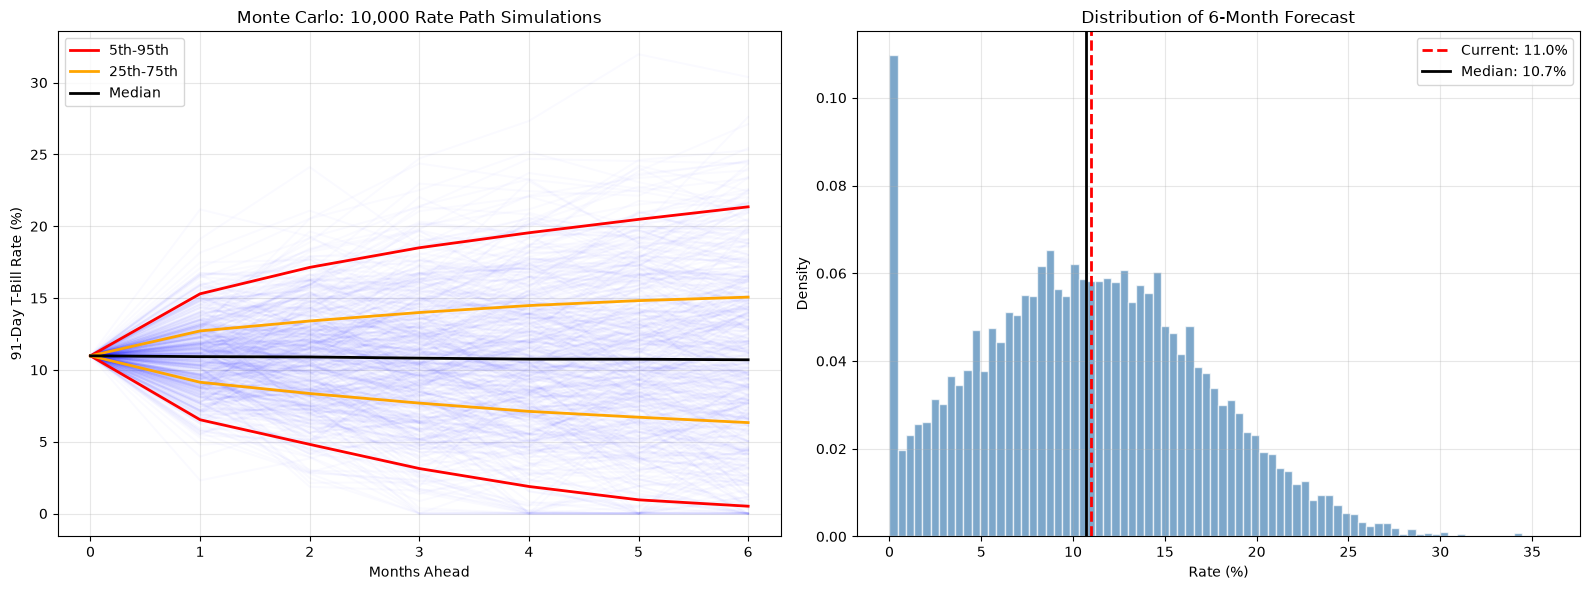

Chart saved!


In [8]:
# ============================================================
# MONTE CARLO VISUALIZATION
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

months_ahead = np.arange(simulations.shape[1])
for i in range(min(500, len(simulations))):
    axes[0].plot(months_ahead, simulations[i], alpha=0.02, color='blue')

for p, color, label in [(5, 'red', '5th-95th'), (25, 'orange', '25th-75th'), (50, 'black', 'Median')]:
    axes[0].plot(months_ahead, np.percentile(simulations, p, axis=0), 
                 color=color, linewidth=2, label=f'{label}')
    if p != 50:
        axes[0].plot(months_ahead, np.percentile(simulations, 100-p, axis=0),
                     color=color, linewidth=2)

axes[0].set_xlabel('Months Ahead')
axes[0].set_ylabel('91-Day T-Bill Rate (%)')
axes[0].set_title('Monte Carlo: 10,000 Rate Path Simulations')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].hist(final_rates, bins=80, density=True, alpha=0.7, color='steelblue', edgecolor='white')
axes[1].axvline(x=df['tbill_91'].iloc[-1], color='red', linewidth=2, 
                linestyle='--', label=f'Current: {df["tbill_91"].iloc[-1]:.1f}%')
axes[1].axvline(x=np.median(final_rates), color='black', linewidth=2,
                linestyle='-', label=f'Median: {np.median(final_rates):.1f}%')
axes[1].set_xlabel('Rate (%)')
axes[1].set_ylabel('Density')
axes[1].set_title('Distribution of 6-Month Forecast')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../data/monte_carlo_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

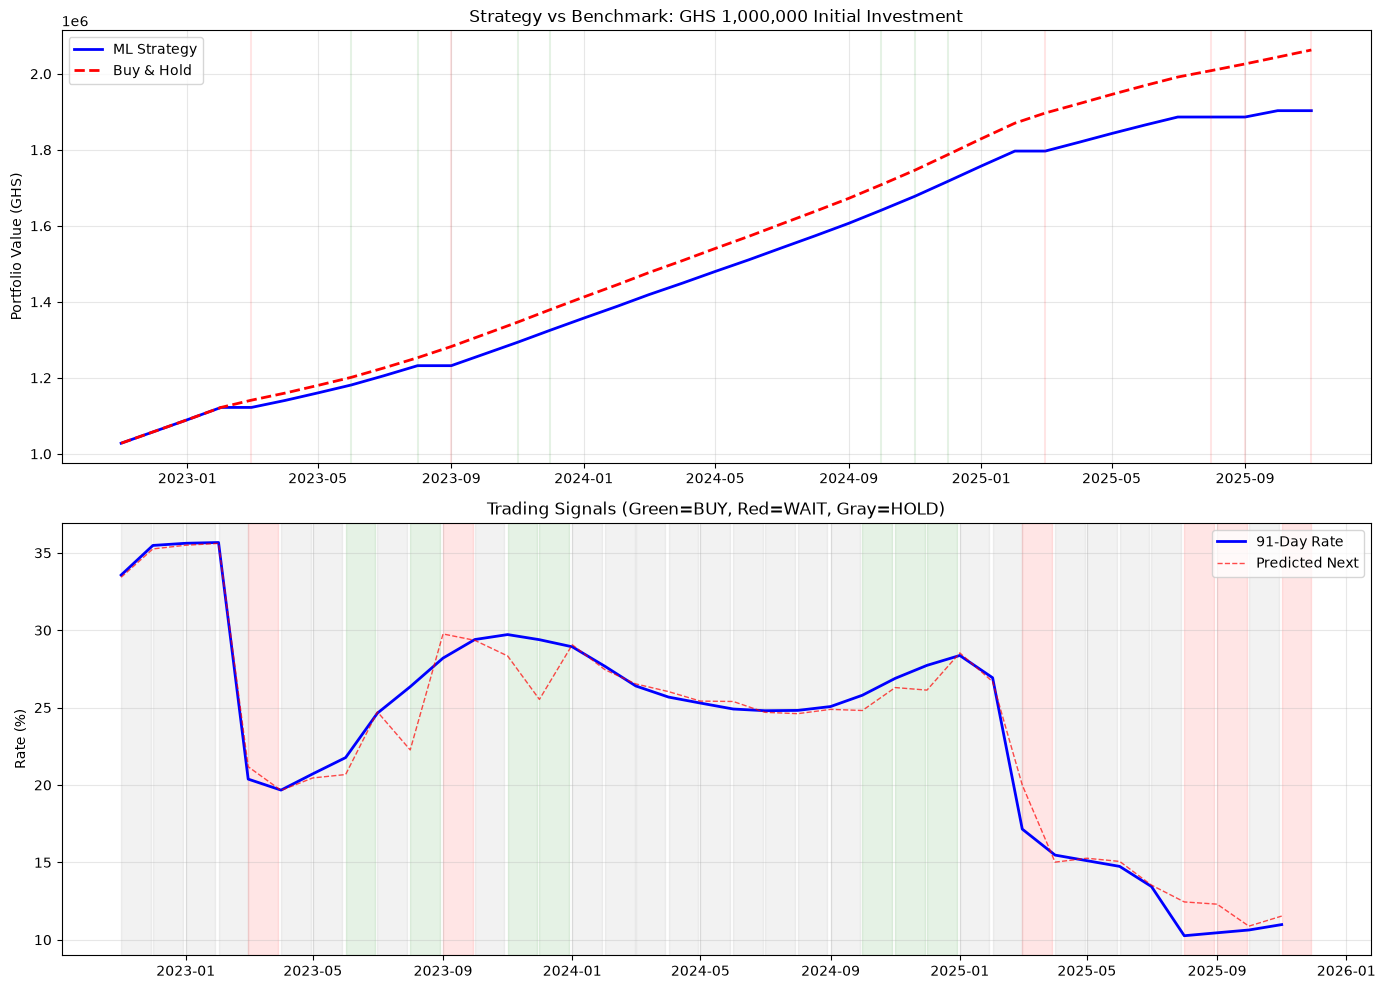

Chart saved!


In [9]:
# ============================================================
# BACKTEST EQUITY CURVE VISUALIZATION
# ============================================================

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

axes[0].plot(strategy_df['date'], strategy_df['value'], 'b-', linewidth=2, label='ML Strategy')
axes[0].plot(benchmark_df['date'], benchmark_df['value'], 'r--', linewidth=2, label='Buy & Hold')
axes[0].set_ylabel('Portfolio Value (GHS)')
axes[0].set_title('Strategy vs Benchmark: GHS 1,000,000 Initial Investment')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

for _, row in strategy_df.iterrows():
    if row['signal'] == 'BUY':
        axes[0].axvline(x=row['date'], color='green', alpha=0.1)
    elif row['signal'] == 'WAIT':
        axes[0].axvline(x=row['date'], color='red', alpha=0.1)

axes[1].plot(pred_df['date'], pred_df['current_rate'], 'b-', linewidth=2, label='91-Day Rate')
axes[1].plot(pred_df['date'], pred_df['predicted_next'], 'r--', linewidth=1, alpha=0.7, label='Predicted Next')

for _, row in pred_df.iterrows():
    color = {'BUY': 'green', 'WAIT': 'red', 'HOLD': 'gray'}[row['signal']]
    axes[1].axvspan(row['date'], row['date'] + pd.Timedelta(days=28), 
                     alpha=0.1, color=color)

axes[1].set_ylabel('Rate (%)')
axes[1].set_title('Trading Signals (Green=BUY, Red=WAIT, Gray=HOLD)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../data/backtest_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

In [10]:
# ============================================================
# GENERATE RECOMMENDATION REPORT
# ============================================================

current_rate = df['tbill_91'].iloc[-1]
last_signal = pred_df['signal'].iloc[-1]
predicted_next = pred_df['predicted_next'].iloc[-1]
predicted_change = pred_df['predicted_change'].iloc[-1]

print(f"{'='*60}")
print(f"GH-YIELD TREASURY RECOMMENDATION REPORT")
print(f"{'='*60}")
print(f"Report Date:           {df['date'].iloc[-1].strftime('%B %Y')}")
print(f"Current 91-Day Rate:   {current_rate:.2f}%")
print(f"Predicted Next Month:  {predicted_next:.2f}%")
print(f"Predicted Change:      {predicted_change:+.2f} basis points")
print(f"Signal:                {last_signal}")
print(f"")
print(f"--- Monte Carlo 6-Month Outlook ---")
print(f"Expected Rate:         {np.mean(final_rates):.2f}%")
print(f"Best Case (95th):      {np.percentile(final_rates, 95):.2f}%")
print(f"Worst Case (5th):      {np.percentile(final_rates, 5):.2f}%")
print(f"P(rate increases):     {(final_rates > current_rate).mean() * 100:.1f}%")
print(f"")
print(f"--- Backtest Performance ---")
print(f"Strategy Return:       {(strategy_df['value'].iloc[-1] / 1_000_000 - 1) * 100:.2f}%")
print(f"Benchmark Return:      {(benchmark_df['value'].iloc[-1] / 1_000_000 - 1) * 100:.2f}%")
print(f"Signal Accuracy:       {(accuracy['signal_correct'] == 'Correct').mean() * 100:.1f}%")
print(f"Sharpe Ratio:          {risk_metrics['strategy_sharpe']:.2f}")
print(f"Max Drawdown:          {risk_metrics['max_drawdown']:.2f}%")
print(f"")
if last_signal == 'BUY':
    print(f"RECOMMENDATION: Lock in the current {current_rate:.2f}% rate.")
    print(f"The model predicts rates will decline next month.")
elif last_signal == 'WAIT':
    print(f"RECOMMENDATION: Hold cash and wait.")
    print(f"The model predicts rates will rise to {predicted_next:.2f}%.")
else:
    print(f"RECOMMENDATION: Maintain current position.")
    print(f"No significant rate change expected.")

GH-YIELD TREASURY RECOMMENDATION REPORT
Report Date:           November 2025
Current 91-Day Rate:   10.98%
Predicted Next Month:  11.53%
Predicted Change:      +0.55 basis points
Signal:                WAIT

--- Monte Carlo 6-Month Outlook ---
Expected Rate:         10.86%
Best Case (95th):      21.35%
Worst Case (5th):      0.51%
P(rate increases):     48.5%

--- Backtest Performance ---
Strategy Return:       90.30%
Benchmark Return:      106.26%
Signal Accuracy:       51.4%
Sharpe Ratio:          6.53
Max Drawdown:          0.00%

RECOMMENDATION: Hold cash and wait.
The model predicts rates will rise to 11.53%.


In [11]:
# ============================================================
# SAVE ALL OUTPUTS
# ============================================================

pred_df.to_csv('../data/predictions_with_signals.csv', index=False)
strategy_df.to_csv('../data/backtest_strategy.csv', index=False)
benchmark_df.to_csv('../data/backtest_benchmark.csv', index=False)

print("All Week 3 outputs saved!")
print(f"\nFiles generated:")
print(f"  - predictions_with_signals.csv")
print(f"  - backtest_strategy.csv")
print(f"  - backtest_benchmark.csv")
print(f"  - monte_carlo_chart.png")
print(f"  - backtest_chart.png")

All Week 3 outputs saved!

Files generated:
  - predictions_with_signals.csv
  - backtest_strategy.csv
  - backtest_benchmark.csv
  - monte_carlo_chart.png
  - backtest_chart.png
